In [118]:
import matplotlib.pyplot as plt
import ast
import pandas as pd
import numpy as np
import cnn_surgery.utils.metrics as metrics

In [119]:
DATASET = 'fashion_mnist'
file_path = f'./../{DATASET}_class_evaluation_baselines_20260121.csv'
df = pd.read_csv(file_path)

In [120]:
# filters
df_filtered = df
df_filtered = df[~df['original_accuracy'].apply(lambda x: 0.0 in ast.literal_eval(x))]
#df_filtered = df_filtered[~df_filtered.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']] < 0.9, axis=1)]
#df_filtered = df_filtered[~df_filtered.apply(lambda row: np.mean(ast.literal_eval(row['original_accuracy'])) < 0.7, axis=1)]
df_filtered = df_filtered[~(df_filtered['distance_travelled'] < 1.0)]
df = df_filtered

In [121]:
df['target_accuracy_before'] = df.apply(lambda row: ast.literal_eval(row['original_accuracy'])[row['target_class']], axis=1)
df['target_accuracy_after'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)
df['target_accuracy_fa'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_fa'])[row['target_class']], axis=1)

df['relative_target_accuracy_after'] = df['target_accuracy_after'] / df['target_accuracy_before']
df['relative_target_accuracy_rv'] = df['target_accuracy_rv'] / df['target_accuracy_before']
df['relative_target_accuracy_fa'] = df['target_accuracy_fa'] / df['target_accuracy_before']

df['mean_retain_accuracy_before'] = df.apply(lambda row: np.mean([ast.literal_eval(row['original_accuracy'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_after'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_rv'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_rv'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)
df['mean_retain_accuracy_fa'] = df.apply(lambda row: np.mean([ast.literal_eval(row['accuracy_after_fa'])[i] for i in range(len(ast.literal_eval(row['original_accuracy']))) if i != row['target_class']]), axis=1)

df['relative_mean_retain_accuracy_after'] = df['mean_retain_accuracy_after'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_rv'] = df['mean_retain_accuracy_rv'] / df['mean_retain_accuracy_before']
df['relative_mean_retain_accuracy_fa'] = df['mean_retain_accuracy_fa'] / df['mean_retain_accuracy_before']

In [122]:
groups = df.groupby('target_class')
tables = {}
relative = False

if relative:
    relative = 'relative_'
else:
    relative = ''

for group in groups:
    target_class, group_df = group  # Unpack the tuple
    table = pd.DataFrame({
        'before': {
            'target': group_df['target_accuracy_before'].mean(),
            'control': group_df['mean_retain_accuracy_before'].mean(),
        },
        'Gradient Ascent': {
            'target': group_df[relative + 'target_accuracy_fa'].mean(),
            'control': group_df[relative + 'mean_retain_accuracy_fa'].mean(),
        },
        'Random Vector': {
            'target': group_df[relative + 'target_accuracy_rv'].mean(),
            'control': group_df[relative + 'mean_retain_accuracy_rv'].mean(),
        },
        'Our Method': {
            'target': group_df[relative + 'target_accuracy_after'].mean(),
            'control': group_df[relative + 'mean_retain_accuracy_after'].mean(),
        },
    })
    tables[target_class] = table

In [123]:
for table in tables:
    print(f'Target Class: {table}')
    print(tables[table].T.round(2))

Target Class: 0
                 target  control
before             0.70     0.73
Gradient Ascent    0.05     0.32
Random Vector      0.60     0.62
Our Method         0.71     0.55
Target Class: 1
                 target  control
before             0.88     0.66
Gradient Ascent    0.11     0.25
Random Vector      0.88     0.64
Our Method         0.87     0.64


In [124]:
print(df.target_accuracy_before.mean())
print(df.mean_retain_accuracy_before.mean())

0.6989265493496557
0.7290313695485846


In [125]:
df['target_over_overall'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1) / df['overall_accuracy']
df['target_over_overall_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1) / df['overall_accuracy_rv']
df['mean_rest_acc'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after'])) if i != row['target_class']]), axis=1)
df['mean_rest_acc_rv'] = df.apply(lambda row: np.mean([x for i,x in enumerate(ast.literal_eval(row['accuracy_after_rv'])) if i != row['target_class']]), axis=1)
df['avg_retain_accuracy'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['avg_retain_accuracy_rv'] = df.apply(lambda row: metrics.avg_retain_accuracy(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
# calculate metrics
df['max_difference'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['mean_difference'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
#df['relative_clipped_negative_mean_difference'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class']), axis=1)
df['relative_target_difference'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after']), row['target_class'], proportional=True), axis=1)
df['relative_target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class'], proportional=True), axis=1)
df['target_accuracy'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after'])[row['target_class']], axis=1)
# metrics for rv
df['max_difference_rv'] = df.apply(lambda row: metrics.max_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['mean_difference_rv'] = df.apply(lambda row: metrics.mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['clipped_negative_mean_difference_rv'] = df.apply(lambda row: metrics.clipped_negative_mean_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_difference_rv'] = df.apply(lambda row: metrics.target_difference(ast.literal_eval(row['original_accuracy']), ast.literal_eval(row['accuracy_after_rv']), row['target_class']), axis=1)
df['target_accuracy_rv'] = df.apply(lambda row: ast.literal_eval(row['accuracy_after_rv'])[row['target_class']], axis=1)

In [126]:
df.target_accuracy.mean()
df.mean_rest_acc.mean()

0.554866870696251

In [127]:
for col in df.columns:
    if 'fa' in col: print(col)

accuracy_after_fa
overall_accuracy_fa
target_accuracy_fa
relative_target_accuracy_fa
mean_retain_accuracy_fa
relative_mean_retain_accuracy_fa


In [128]:
df

,model_idx,original_accuracy,original_overall_accuracy,accuracy_after,overall_accuracy,target_class,dataset,lr,stop_threshold,l2_penalty,...,mean_difference,clipped_negative_mean_difference,target_difference,relative_target_difference,relative_target_difference_rv,target_accuracy,max_difference_rv,mean_difference_rv,clipped_negative_mean_difference_rv,target_difference_rv
0,0,"[0.766, 0.878, 0.659, 0.679, 0.581, 0.69, 0.16...",0.7082,"[0.947, 0.857, 0.001, 0.32, 0.75, 0.801, 0.015...",0.6096,0,fashion_mnist,0.1,0.9,0.0,...,-0.310667,-0.167444,-0.181,-0.236292,0.108355,0.947,-0.498,0.000778,-0.041778,0.083
1,1,"[0.529, 0.909, 0.385, 0.239, 0.702, 0.853, 0.0...",0.5407,"[0.667, 0.216, 0.6, 0.581, 0.54, 0.0, 0.004, 0...",0.4924,0,fashion_mnist,0.1,0.9,0.0,...,-0.207000,-0.223556,-0.138,-0.260870,1.000000,0.667,-0.299,0.314667,0.283556,0.529
2,2,"[0.782, 0.903, 0.712, 0.8, 0.6, 0.806, 0.166, ...",0.7513,"[0.857, 0.918, 0.01, 0.518, 0.865, 0.979, 0.0,...",0.5776,0,fashion_mnist,0.1,0.9,0.0,...,-0.276333,-0.251667,-0.075,-0.095908,-0.015345,0.857,-0.345,-0.059667,-0.070556,-0.012
3,3,"[0.721, 0.867, 0.289, 0.652, 0.722, 0.399, 0.1...",0.6346,"[0.478, 0.886, 0.991, 0.674, 0.0, 0.0, 0.0, 0....",0.5604,0,fashion_mnist,0.1,0.9,0.0,...,0.187556,0.101444,0.243,0.337032,0.130374,0.478,-0.550,-0.014000,-0.050222,0.094
4,4,"[0.808, 0.945, 0.753, 0.828, 0.841, 0.871, 0.4...",0.8300,"[0.679, 0.942, 0.872, 0.854, 0.238, 0.804, 0.6...",0.7570,0,fashion_mnist,0.1,0.9,0.0,...,0.062222,0.025444,0.129,0.159653,-0.155941,0.679,-0.377,-0.194222,-0.070111,-0.126
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2573,1073,"[0.798, 0.867, 0.921, 0.731, 0.073, 0.737, 0.0...",0.6835,"[0.779, 0.863, 0.94, 0.74, 0.005, 0.717, 0.044...",0.6760,1,fashion_mnist,0.1,0.9,0.0,...,-0.003889,-0.008222,0.004,0.004614,0.000000,0.863,-0.055,-0.008444,-0.022778,0.000
2708,1208,"[0.768, 0.872, 0.719, 0.706, 0.005, 0.759, 0.2...",0.6772,"[0.732, 0.91, 0.0, 0.685, 0.0, 0.841, 0.722, 0...",0.6507,1,fashion_mnist,0.1,0.9,0.0,...,-0.071667,-0.098000,-0.038,-0.043578,0.026376,0.910,-0.262,-0.000111,-0.024000,0.023
2739,1239,"[0.697, 0.885, 0.283, 0.694, 0.746, 0.72, 0.17...",0.6855,"[0.711, 0.894, 0.358, 0.653, 0.701, 0.703, 0.1...",0.6859,1,fashion_mnist,0.1,0.9,0.0,...,-0.009556,-0.011556,-0.009,-0.010169,-0.009040,0.894,-0.291,-0.038444,-0.051556,-0.008
2904,1404,"[0.723, 0.898, 0.902, 0.674, 0.023, 0.789, 0.0...",0.6594,"[0.785, 0.891, 0.789, 0.643, 0.113, 0.825, 0.1...",0.6597,1,fashion_mnist,0.1,0.9,0.0,...,0.008111,-0.017889,0.007,0.007795,-0.003341,0.891,-0.037,-0.006444,-0.008444,-0.003


<Axes: ylabel='Frequency'>

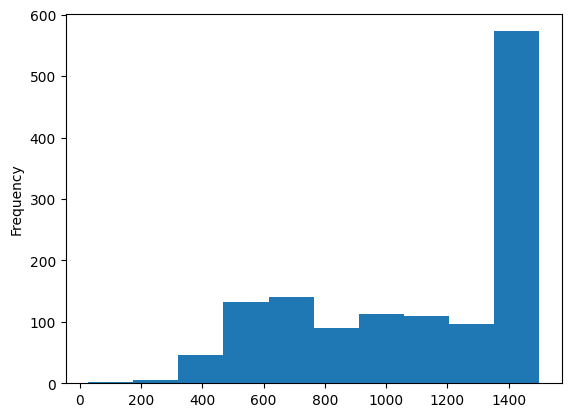

In [129]:
df.steps.plot.hist()